In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
import warnings
warnings.filterwarnings("ignore")

## Explanation

The first step involves importing the required Python libraries for data manipulation, visualization, and machine learning.
pandas and numpy are used for data handling and numerical operations, while matplotlib and seaborn are used to create visualizations for exploratory data analysis.

In [2]:
df = pd.read_csv(r"C:\Users\GLXTCH\Documents\techcrush\healthcare-dataset-stroke-data.csv")
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [3]:
print("Shape:", df.shape)
print("\nTarget distribution:")
print(df["stroke"].value_counts(normalize=True).round(4) * 100)

print("\nMissing values:")
print(df.isna().sum())

# Drop useless 
df = df.drop(columns=["id"])

# Very rare gender category → drop (only 1 row usually)
df = df[df["gender"] != "Other"].copy()

print("\nAfter cleaning:", df.shape)

Shape: (5110, 12)

Target distribution:
stroke
0    95.13
1     4.87
Name: proportion, dtype: float64

Missing values:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

After cleaning: (5109, 11)


## Explanation

This step examines the structure of the dataset and the distribution of the target variable. Understanding class distribution is important because stroke prediction datasets are typically highly imbalanced.

Which is why SMOTE was used at the end

In [4]:
# Age-group based median imputation (much better than global median)
age_bins = [0, 18, 30, 40, 50, 60, 70, 80, 200]
age_labels = ["0-17", "18-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80+"]
df["age_group"] = pd.cut(df["age"], bins=age_bins, labels=age_labels, right=False)

# Create missing indicator (very strong signal in this dataset)
df["bmi_missing"] = df["bmi"].isna().astype(int)

df["bmi"] = df["bmi"].fillna(df.groupby("age_group")["bmi"].transform("median"))

# Just to see if it worked at all
print("Remaining missing BMI:", df["bmi"].isna().sum())          # should be 0 or very few (only if age is NaN)
print("Rows that were originally missing:", df["bmi_missing"].sum())


Remaining missing BMI: 0
Rows that were originally missing: 201


# Explanation 

Missing BMI values were imputed using the median BMI within age groups rather than a global median. This approach preserves realistic physiological patterns since BMI distributions vary significantly across age categories.

# Exploratory Data Analysis

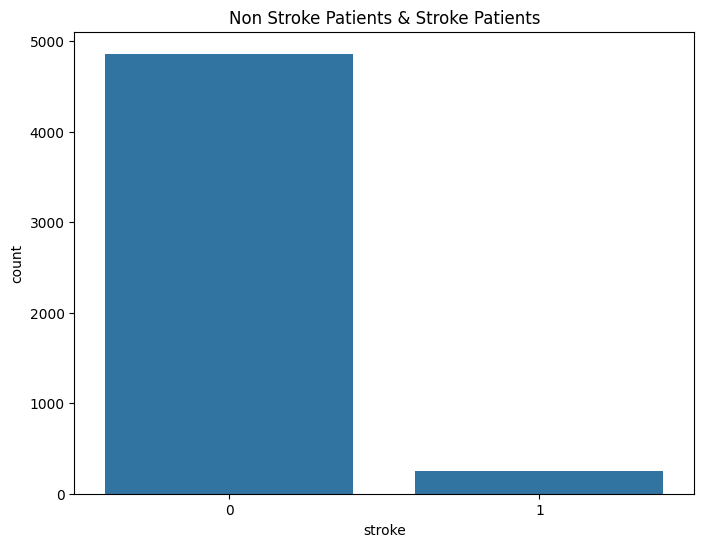

In [5]:
# Target Variable Analysis
df['stroke'].value_counts(normalize=True) * 100

plt.figure(figsize=(8,6))
sns.countplot(x='stroke', data=df)
plt.title("Non Stroke Patients & Stroke Patients")
plt.show()

The dataset shows a strong class imbalance, with significantly fewer stroke cases compared to non-stroke cases. This imbalance can bias machine learning models toward predicting the majority class.

In [6]:
# Age vs Stroke
(pd.crosstab(df['age_group'], df['stroke'], normalize='index') * 100).round(2)

stroke,0,1
age_group,,
0-17,99.77,0.23
18-29,100.00,0.00
30-39,99.08,0.92
40-49,98.36,1.64
50-59,94.24,5.76
60-69,92.43,7.57
70-79,83.48,16.52
80+,78.49,21.51


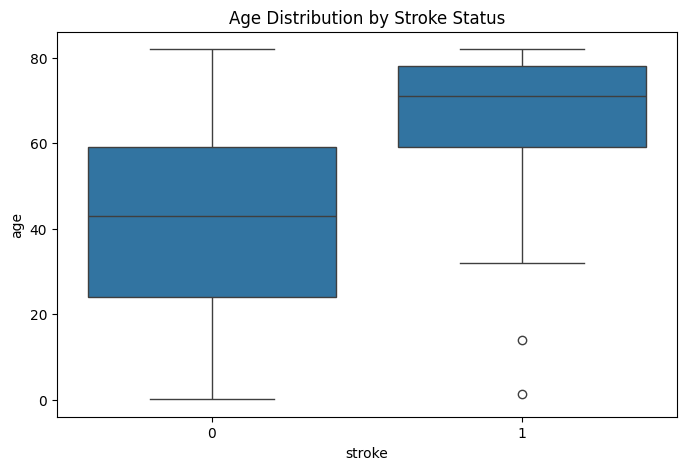

In [7]:
# Age vs Stroke Visuailzation
plt.figure(figsize=(8,5))
sns.boxplot(x='stroke', y='age', data=df)
plt.title("Age Distribution by Stroke Status")
plt.show()

Patients who experienced strokes tend to have higher ages. This aligns with medical evidence that stroke risk increases significantly with age.

In [8]:
df = df.drop(columns=["age_group"])  # cleanup

In [9]:
# Gender vs Stroke
(pd.crosstab(df['gender'], df['stroke'], normalize='index') * 100).round(2)

stroke,0,1
gender,,
Female,95.29,4.71
Male,94.89,5.11


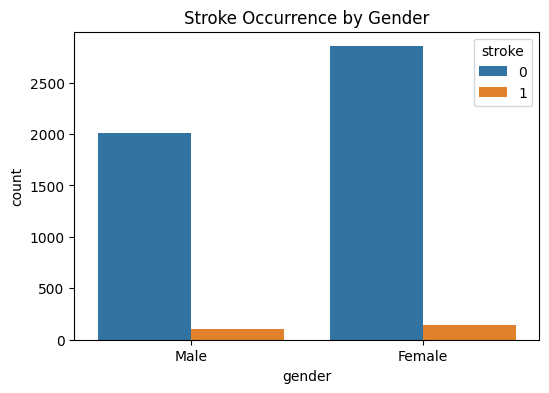

In [10]:
# Stroke occurence in gender visualization

plt.figure(figsize=(6,4))
sns.countplot(x='gender', hue='stroke', data=df)
plt.title("Stroke Occurrence by Gender")
plt.show()

Stroke distribution across gender appears relatively balanced, though slight variation may exist.
Further statistical testing may be required to confirm significance.

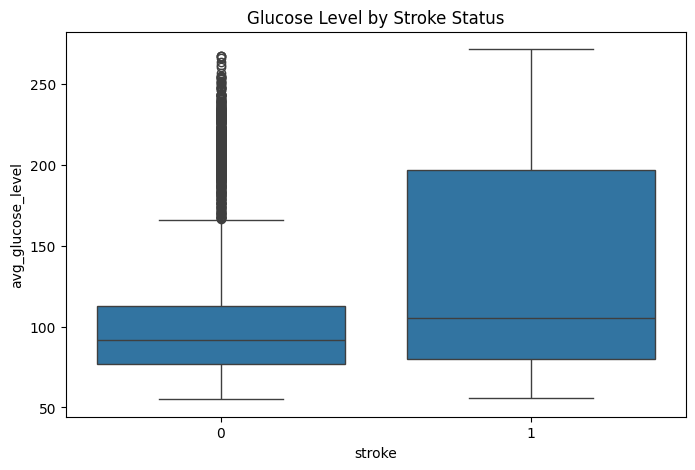

In [11]:
# Average Glucose Level vs Stroke
plt.figure(figsize=(8,5))
sns.boxplot(x='stroke', y='avg_glucose_level', data=df)
plt.title("Glucose Level by Stroke Status")
plt.show()

Stroke patients tend to exhibit higher average glucose levels, suggesting metabolic conditions may contribute to stroke risk.

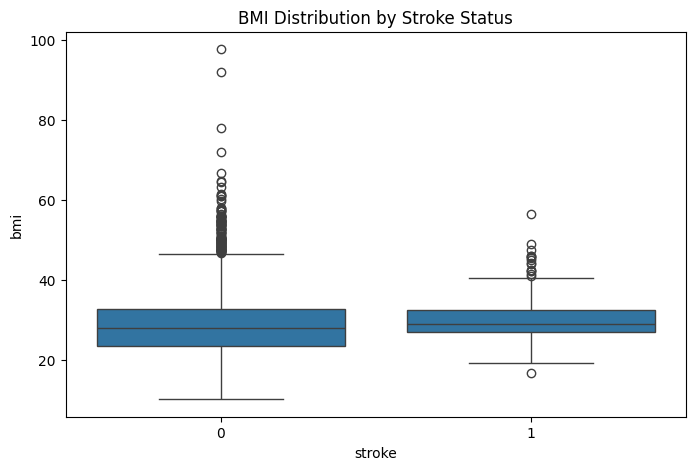

In [12]:
# BMI vs Stroke

plt.figure(figsize=(8,5))
sns.boxplot(x='stroke', y='bmi', data=df)
plt.title("BMI Distribution by Stroke Status")
plt.show()

BMI shows moderate variation between groups.

While obesity is medically linked to stroke, its independent predictive strength should be evaluated during modeling.

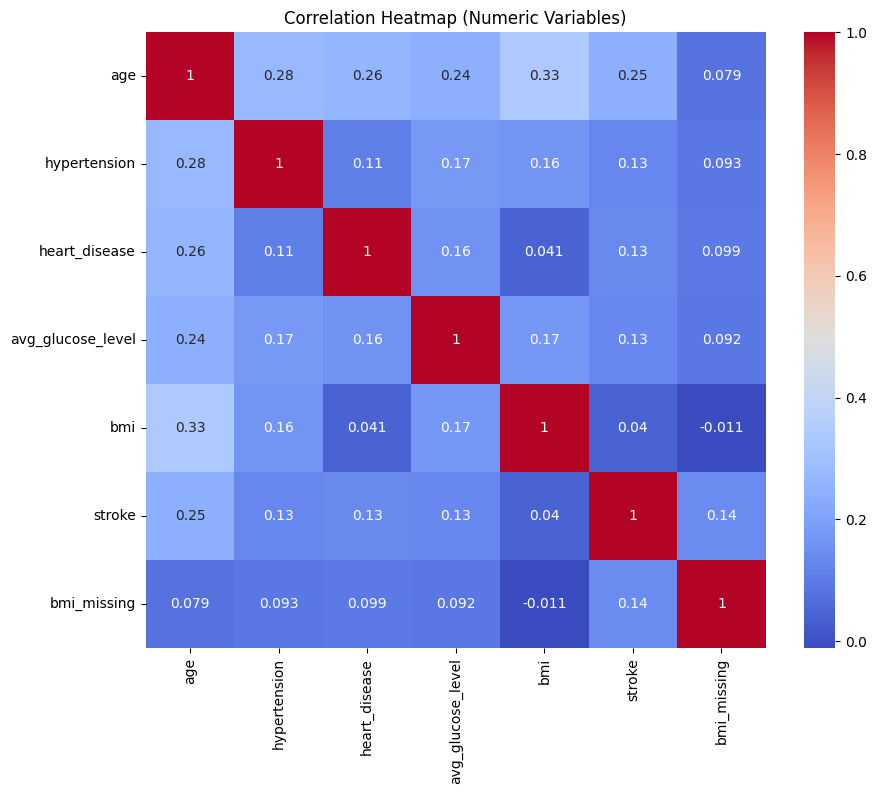

In [13]:
# Correlation Heatmap

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Numeric Variables)")
plt.show()

The Correlation analysis shows that age, hypertension, heart disease, and glucose levels show the strongest association with stroke occurrence.

In [14]:
# Clinically useful binary features
df["age_over_60"] = (df["age"] >= 60).astype(int)
df["high_glucose"] = (df["avg_glucose_level"] >= 170).astype(int)
df["high_risk_combo"] = df["hypertension"] + df["heart_disease"] + df["age_over_60"]

Additional features were engineered based on clinical knowledge. Age above 60 and elevated glucose levels are known stroke risk factors, so binary indicators were created to capture these thresholds.

In [15]:
# Binary encoding for simple features
df["ever_married"] = df["ever_married"].map({"Yes": 1, "No": 0})
df["Residence_type"] = df["Residence_type"].map({"Urban": 1, "Rural": 0})

print("Missing values after cleaning:\n", df.isna().sum())

Missing values after cleaning:
 gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
bmi_missing          0
age_over_60          0
high_glucose         0
high_risk_combo      0
dtype: int64


Categorical variables such as gender, work type, and smoking status were transformed using one-hot encoding to convert them into a numerical format suitable for machine learning algorithms.

# FEATURES PROCESSING

In [17]:
categorical_features = ["gender", "work_type", "smoking_status"]
numerical_features = [
    "age", "avg_glucose_level", "bmi", "hypertension", "heart_disease",
    "ever_married", "Residence_type", "age_over_60", "high_glucose",
    "high_risk_combo", "bmi_missing"
]

X = df[numerical_features + categorical_features]
y = df["stroke"]

In [18]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ])

A preprocessing pipeline was created to ensure that numerical and categorical features are processed appropriately. Numerical features are scaled using standardization, while categorical variables are one-hot encoded.

# MODEL PIPELINES

In [19]:
def evaluate_model(model_name, classifier):
    print(f"\n=== {model_name} ===")
    
    pipe = ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("classifier", classifier)
    ])
    
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
    
    scoring = {
        "roc_auc": "roc_auc",
        "pr_auc": "average_precision",
        "f1": "f1",
        "recall": "recall",
        "precision": "precision"
    }
    
    scores = cross_validate(
        pipe, X, y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    
    for metric in scoring:
        mean = scores[f"test_{metric}"].mean()
        std  = scores[f"test_{metric}"].std()
        print(f"{metric:12} : {mean:.4f} ± {std:.4f}")

Because stroke cases represent a small minority of the dataset, SMOTE was applied to generate synthetic samples of the minority class. This helps the model learn patterns associated with stroke cases more effectively.

In [20]:
# Logistic Regression (with balanced class weight as alternative)
evaluate_model("Logistic Regression",
               LogisticRegression(class_weight="balanced", max_iter=1000))

# Random Forest
evaluate_model("Random Forest",
               RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))

# XGBoost – usually strongest performer on this dataset
evaluate_model("XGBoost",
               XGBClassifier(
                   scale_pos_weight = (y==0).sum() / (y==1).sum(),
                   eval_metric="aucpr",
                   random_state=42,
                   n_estimators=250,
                   max_depth=4,
                   learning_rate=0.04,
                   reg_lambda=1.2
               ))


=== Logistic Regression ===
roc_auc      : 0.8459 ± 0.0163
pr_auc       : 0.2298 ± 0.0367
f1           : 0.2313 ± 0.0143
recall       : 0.7630 ± 0.0514
precision    : 0.1364 ± 0.0088

=== Random Forest ===
roc_auc      : 0.8052 ± 0.0128
pr_auc       : 0.1465 ± 0.0155
f1           : 0.0928 ± 0.0395
recall       : 0.0697 ± 0.0293
precision    : 0.1463 ± 0.0735

=== XGBoost ===
roc_auc      : 0.7828 ± 0.0161
pr_auc       : 0.1676 ± 0.0320
f1           : 0.1868 ± 0.0114
recall       : 0.7067 ± 0.0563
precision    : 0.1077 ± 0.0068


Multiple classification algorithms were evaluated to compare predictive performance. Logistic Regression provides a baseline linear model, Random Forest captures nonlinear relationships through ensemble trees, and XGBoost leverages gradient boosting for strong predictive performance.


Training final XGBoost model on full dataset...

Top 12 Most Important Features:
age                               0.169919
work_type_children                0.107136
gender_Male                       0.087056
smoking_status_formerly smoked    0.080373
work_type_Private                 0.071188
smoking_status_smokes             0.068784
smoking_status_never smoked       0.059429
work_type_Self-employed           0.057833
bmi_missing                       0.049202
ever_married                      0.044186
Residence_type                    0.040021
bmi                               0.039334
dtype: float32


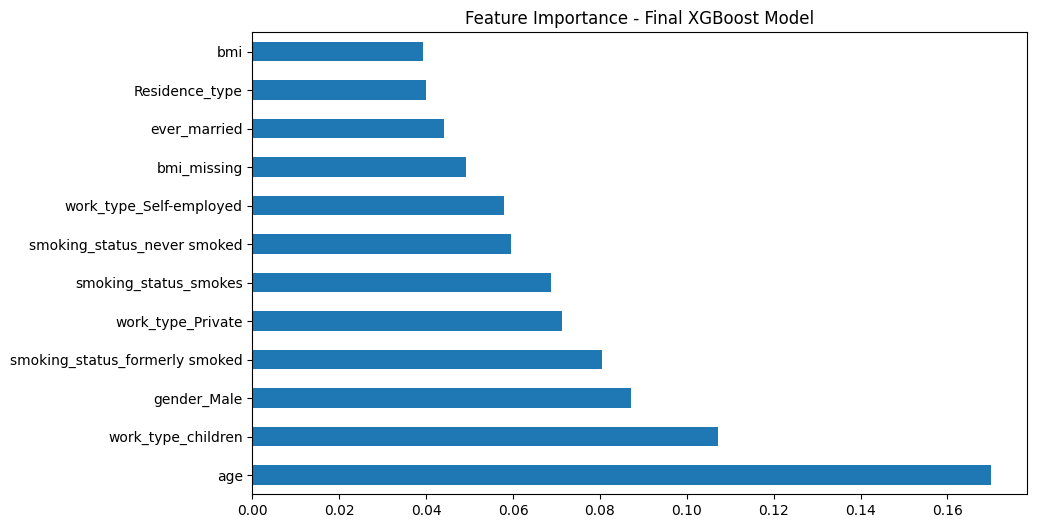


Done. Consider:
- SHAP values for better interpretability
- Threshold tuning (for higher recall)
- Cost-sensitive evaluation if deployed in healthcare


In [24]:
print("\nTraining final XGBoost model on full dataset...")

final_pipe = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", XGBClassifier(
        scale_pos_weight = (y==0).sum() / (y==1).sum(),
        eval_metric="aucpr",
        random_state=42,
        n_estimators=250,
        max_depth=4,
        learning_rate=0.04
    ))
])

final_pipe.fit(X, y)

# Feature names after preprocessing (for importance)
feature_names = (
    numerical_features +
    list(final_pipe.named_steps["preprocessor"]
         .named_transformers_["cat"]["onehot"]
         .get_feature_names_out(categorical_features))
)

importances = pd.Series(
    final_pipe.named_steps["classifier"].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print("\nTop 12 Most Important Features:")
print(importances.head(12))

plt.figure(figsize=(10,6))
importances.head(12).sort_values().plot(kind="barh")
plt.title("Feature Importance - Final XGBoost Model")
plt.gca().invert_yaxis()
plt.show()

print("\nDone. Consider:")
print("- SHAP values for better interpretability")
print("- Threshold tuning (for higher recall)")
print("- Cost-sensitive evaluation if deployed in healthcare")

## Interpretation

Feature importance analysis from the XGBoost model showed that age was the most influential predictor of stroke risk, followed by lifestyle and demographic variables such as work type, smoking status, and marital status. Smoking-related variables were particularly important, aligning with established medical evidence that smoking increases stroke risk. Additionally, the presence of missing BMI values was found to carry predictive signal, suggesting that incomplete health records may correlate with patient risk profiles.